<a href="https://colab.research.google.com/github/aerau05/air_fryers/blob/main/demand_estimation_air_fryers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Analysis

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

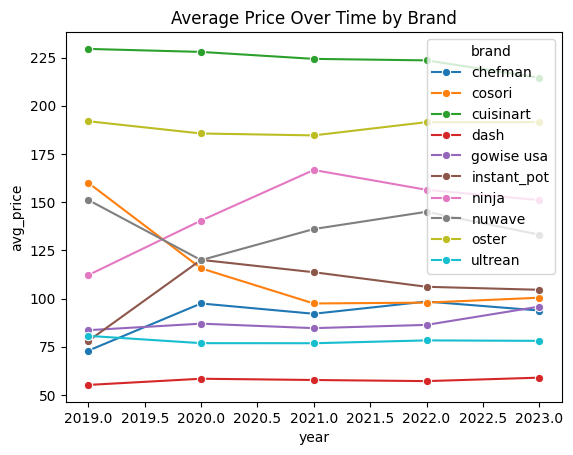

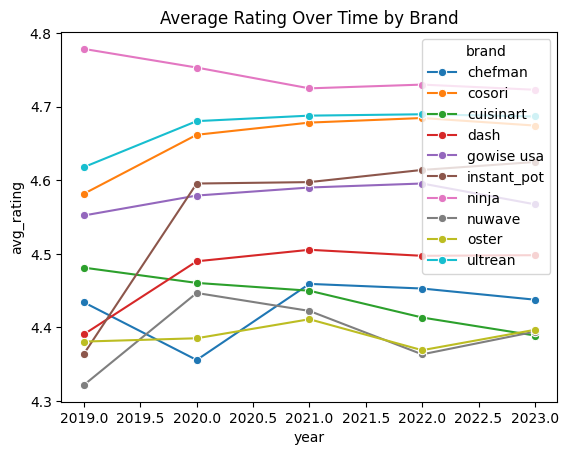

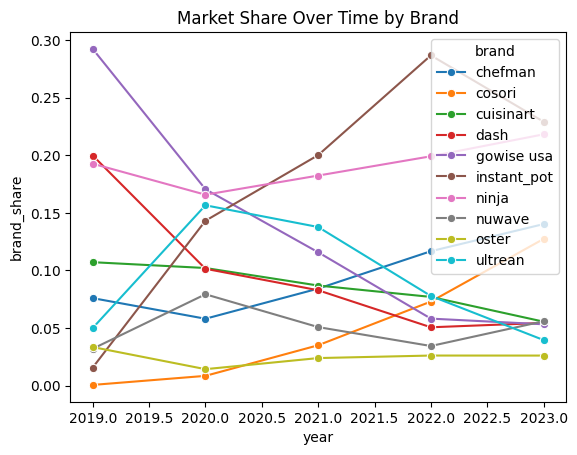

compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000          0.864518   
ultrean           1.000000           0.000000          0.830181   

             rotisserie_share 

In [4]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")

# 1.1
print(df.shape)
print(df.head())
print(df.groupby("year")["brand_share"].sum())

feature_cols = [
    "avg_price",
    "avg_rating",
    "brand_share",]

# 1.2
print("Unique brands:", df["brand"].nunique())
print("Brands:", df["brand"].unique())
print("Years:", sorted(df["year"].unique()))

#1.3
# average price over time
plt.figure()
sns.lineplot(data=df, x="year", y="avg_price", hue="brand", marker="o")
plt.title("Average Price Over Time by Brand")
plt.show()
# average rating over time
plt.figure()
sns.lineplot(data=df, x="year", y="avg_rating", hue="brand", marker="o")
plt.title("Average Rating Over Time by Brand")
plt.show()
# market share over time
plt.figure()
sns.lineplot(data=df, x="year", y="brand_share", hue="brand", marker="o")
plt.title("Market Share Over Time by Brand")
plt.show()

# 1.4 summarize product characteristics
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]
print(df[feature_cols].mean().sort_values(ascending=False))
print(df.groupby("brand")[feature_cols].mean())

**Part 1. Data Analysis**

**Question 4:** Summarize the product characteristics: Which features are common? Which features are rare? Are there brands that seem to specialize in different product types?

Based on feature averages, common features included a compact design, which is nearly universal, and oven-style designs. Rare features include dual basket and rotisserie and window features. Brands like Cuisinart tend to emphasize oven-style air fryers, other brands include more rotisserie features, indicating a focus on multifunctionality, but most brands heavily concentrate on compact designs, suggesting this is the standard market offering. Overall, differentiation across brands comes more from price and product mix rather than entirely unique features.

**Question 5:** Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

The air fryer market from 2019 to 2023 consists of 10 major brands with market shares that sum to one within each year, confirming a properly defined market. The market appears moderately concentrated, with a few dominant brands such as GoWISE USA and Dash holding large shares, while others like Cosori initially have very small shares but grow over time. Prices bary substantially across brands, with premium brands like Cuisinart consistently charging higher average prices, while brands like Dash and Chefman compete in the lower-price segment. Average ratings are relatively high across all brands (all above 4.3), suggesting strong consumer satisfaction with little differentiation on quality perception. Over time, market shares and prices appear relatively stable, though some brands show gradual growth or decline, indicating mild competition rather than rapid market disruption.

## 2. Demand Estimation

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [6]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")

feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

print("Shape:", df.shape)
print("Brands:", sorted(df['brand'].unique()))
print("Years:", sorted(df['year'].unique()))
print("\nBrand-share sums by year (should each be 1.0):")
print(df.groupby('year')['brand_share'].sum().round(4))
df.head()

Shape: (50, 15)
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Brand-share sums by year (should each be 1.0):
year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [7]:
y = df["log_brand_share"]

brand_dummies = pd.get_dummies(df["brand"],
                               prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df["year"].astype(str),
                              prefix="year", drop_first=True, dtype=int)

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_cols],
     brand_dummies,
     year_dummies],
    axis=1,
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_,
})

print("R-squared:", round(r2, 4))
print("Intercept:", round(model.intercept_, 4))
coef_table

R-squared: 0.7635
Intercept: -13.3049


,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,brand_cosori,2.551946
8,brand_cuisinart,6.422436
9,brand_dash,0.176655


In [8]:
main_coefs = coef_table[coef_table['feature'].isin(
    ['avg_price', 'avg_rating'] + feature_cols
)].reset_index(drop=True)

brand_coefs = (coef_table[coef_table['feature'].str.startswith('brand_')]
               .sort_values('coefficient', ascending=False)
               .reset_index(drop=True))

year_coefs = (coef_table[coef_table['feature'].str.startswith('year_')]
              .sort_values('coefficient', ascending=False)
              .reset_index(drop=True))

print("--- Price, rating, characteristics ---")
print(main_coefs.to_string(index=False))
print("\n--- Brand dummies (vs. chefman) ---")
print(brand_coefs.to_string(index=False))
print("\n--- Year dummies (vs. 2019) ---")
print(year_coefs.to_string(index=False))

--- Price, rating, characteristics ---
          feature  coefficient
        avg_price    -0.037668
       avg_rating     0.287517
    compact_share     9.815304
dual_basket_share    -9.509686
 oven_style_share     1.941774
 rotisserie_share    -5.674054
     window_share    12.880298

--- Brand dummies (vs. chefman) ---
          feature  coefficient
  brand_cuisinart     6.422436
      brand_ninja     5.838705
brand_instant_pot     4.626260
 brand_gowise usa     3.938996
      brand_oster     3.928074
     brand_nuwave     3.544883
     brand_cosori     2.551946
    brand_ultrean     0.942399
       brand_dash     0.176655

--- Year dummies (vs. 2019) ---
  feature  coefficient
year_2020     0.119071
year_2021     0.041900
year_2023    -0.003307
year_2022    -0.098860


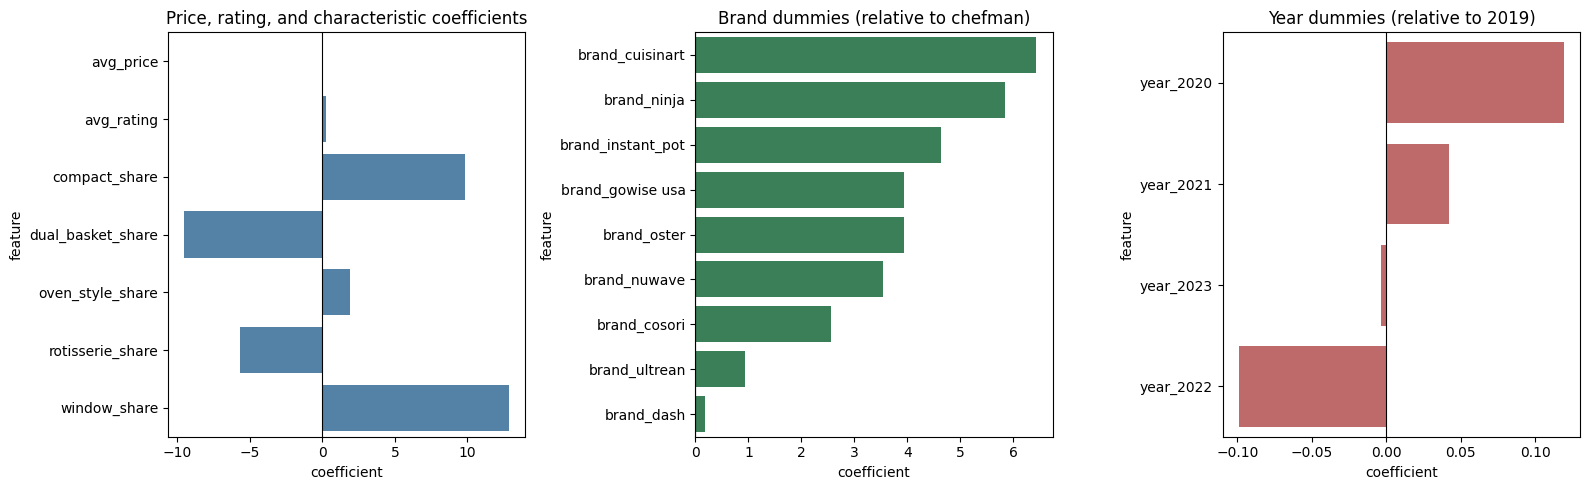

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=main_coefs, y='feature', x='coefficient',
            ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Price, rating, and characteristic coefficients')

sns.barplot(data=brand_coefs, y='feature', x='coefficient',
            ax=axes[1], color='seagreen')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Brand dummies (relative to chefman)')

sns.barplot(data=year_coefs, y='feature', x='coefficient',
            ax=axes[2], color='indianred')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Year dummies (relative to 2019)')

plt.tight_layout()
plt.show()

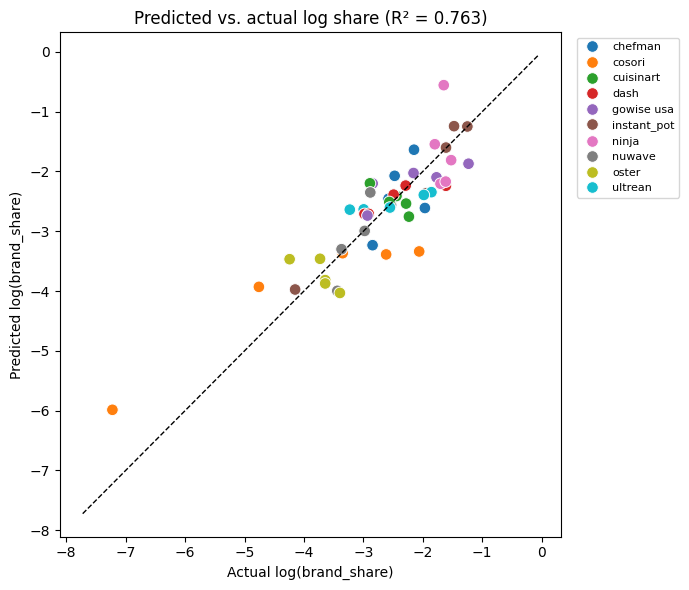

In [10]:
fit_df = df[['brand', 'year']].copy()
fit_df['actual'] = y.values
fit_df['predicted'] = predicted_log_share

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=fit_df, x='actual', y='predicted', hue='brand',
                s=70, ax=ax)
lims = [fit_df[['actual', 'predicted']].min().min() - 0.5,
        fit_df[['actual', 'predicted']].max().max() + 0.5]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual log(brand_share)')
ax.set_ylabel('Predicted log(brand_share)')
ax.set_title(f'Predicted vs. actual log share (R² = {r2:.3f})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print("Price coefficient saved for Part 3:", price_coef)

predictions = df.copy()
predictions['predicted_log_share'] = predicted_log_share
predictions.to_csv('air_fryers_with_predictions.csv', index=False)
coef_table.to_csv('air_fryers_demand_coefficients.csv', index=False)
print("Wrote air_fryers_with_predictions.csv and air_fryers_demand_coefficients.csv")

Price coefficient saved for Part 3: -0.03766765298429372
Wrote air_fryers_with_predictions.csv and air_fryers_demand_coefficients.csv


### Answers to part 2 questions

**1. What is the estimated price coefficient, $\hat{\beta}_{price}$?**

$\hat{\beta}_{price} \approx -0.0377$. A one-dollar increase in average price lowers $\log(s_{bt})$ by about 0.038.

**2. Is it negative? Why is that important?**

Yes, the coefficient is negative. This matters because it matches basic economic intuition where demand should slope downward, meaning consumers prefer cheaper air fryers when other characteristics are held constant.

**3. Which product features are associated with higher demand?**

Based on the characteristic coefficients, `window_share` (≈ +12.88) and `compact_share` (≈ +9.82) are most strongly associated with higher demand, with `oven_style_share` (≈ +1.94) showing a smaller positive effect. By contrast, `rotisserie_share` (≈ −5.67) and `dual_basket_share` (≈ −9.51) are associated with lower demand conditional on price, rating, and brand.


**4. Which brand dummy coefficients are largest?**

Relative to the dropped brand `chefman`, the largest brand dummies are `cuisinart` (≈ +6.42), `ninja` (≈ +5.84), and `instant_pot` (≈ +4.63), followed by `gowise usa` (≈ +3.94) and `oster` (≈ +3.93). These brands have substantially higher mean log-share than chefman after controlling for price, rating, and product mix, meaning they have real brand pull that the observed characteristics don't explain.

**5. Which year dummy coefficients are largest?**

The largest year dummy coefficients are `year_2020` (≈ +0.119, the largest positive) and `year_2022` (≈ −0.099, the largest negative), both relative to the dropped year 2019. The full ordering is `year_2020` (≈ +0.119), `year_2021` (≈ +0.042), `year_2023` (≈ −0.003), and `year_2022` (≈ −0.099). The coefficients are small in absolute terms, reflecting that in this multinomial-logit setup the year dummies mainly absorb the year-specific normalizing constant of the share equation. Their small size says the within-market structure is fairly stable year to year, and the mild 2020 bump is consistent with a pandemic-era demand surge for kitchen appliances.

**6. What is the model's $R^2$?**

$R^2 \approx 0.764$, meaning it explains about 76% of the variation in log brand share.